# 01 — Convergence Analysis

Phân tích hội tụ của thuật toán tối ưu hoá topology cho từng seed shape.

**Nguồn dữ liệu:** `data/Shape_Initial_shear/` và `data/Shape_Initial_stiff/` — mỗi thư mục con chứa:
- `iteration_data.csv`: 4 cột `iterations`, `volume_fractions`, `poisson_ratios_v12`, `poisson_ratios_v21`
- `iteration_*.png`: ảnh topology qua từng iteration

**Output figures:** `outputs/figures/convergence_*.png`

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path

# ── config ──
DATA_ROOT = Path('../data')
OUTPUT_DIR = Path('../outputs/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print('Setup OK')

Setup OK


## 1. Load dữ liệu

In [14]:
def load_all_csv(base_dir, label):
    """Đọc tất cả iteration_data.csv từ các thư mục con."""
    rows = []
    for seed_dir in sorted(base_dir.iterdir()):
        if not seed_dir.is_dir():
            continue
        csv_path = seed_dir / 'iteration_data.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df['seed'] = seed_dir.name
        df['condition'] = label
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

df_shear = load_all_csv(DATA_ROOT / 'Shape_Initial_shear', 'shear')
df_stiff = load_all_csv(DATA_ROOT / 'Shape_Initial_stiff', 'stiff')
df = pd.concat([df_shear, df_stiff], ignore_index=True)

print(f'shear: {len(df_shear)} rows, {df_shear["seed"].nunique()} seeds')
print(f'stiff: {len(df_stiff)} rows, {df_stiff["seed"].nunique()} seeds')
print(f'total: {len(df)} rows')
df.head()

shear: 531 rows, 10 seeds
stiff: 366 rows, 10 seeds
total: 897 rows


,iterations,volume_fractions,poisson_ratios_v12,poisson_ratios_v21,seed,condition
0,1,0.352160,0.336780,0.336780,Cross_regtangular_shear,shear
1,2,0.400000,0.253337,0.253337,Cross_regtangular_shear,shear
2,3,0.399997,0.238307,0.238307,Cross_regtangular_shear,shear
3,4,0.399998,0.202392,0.202392,Cross_regtangular_shear,shear
4,5,0.399998,0.161564,0.161564,Cross_regtangular_shear,shear


## 2. Convergence — Poisson's ratio ν₁₂

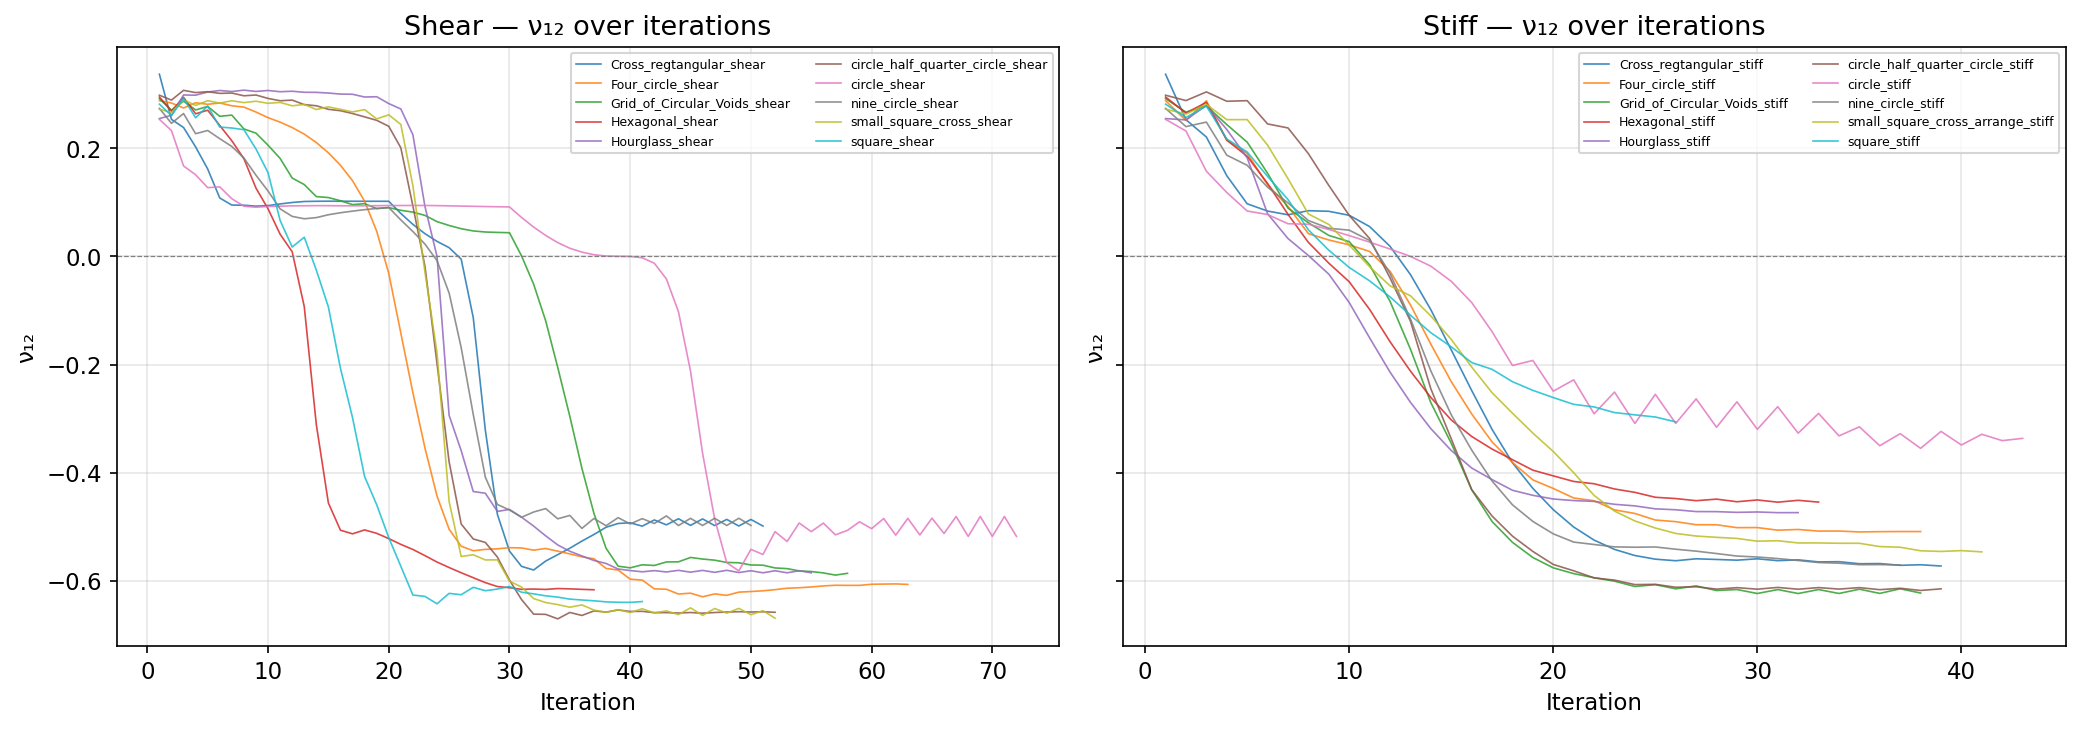

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = df[df['condition'] == cond]
    for seed, grp in sub.groupby('seed'):
        grp = grp.sort_values('iterations')
        ax.plot(grp['iterations'], grp['poisson_ratios_v12'],
                label=seed, linewidth=0.8, alpha=0.85)
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.6)
    ax.set_title(f'{label} — ν₁₂ over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('ν₁₂')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'convergence_v12_shear_stiff.png')
plt.show()

## 3. Convergence — Volume fraction

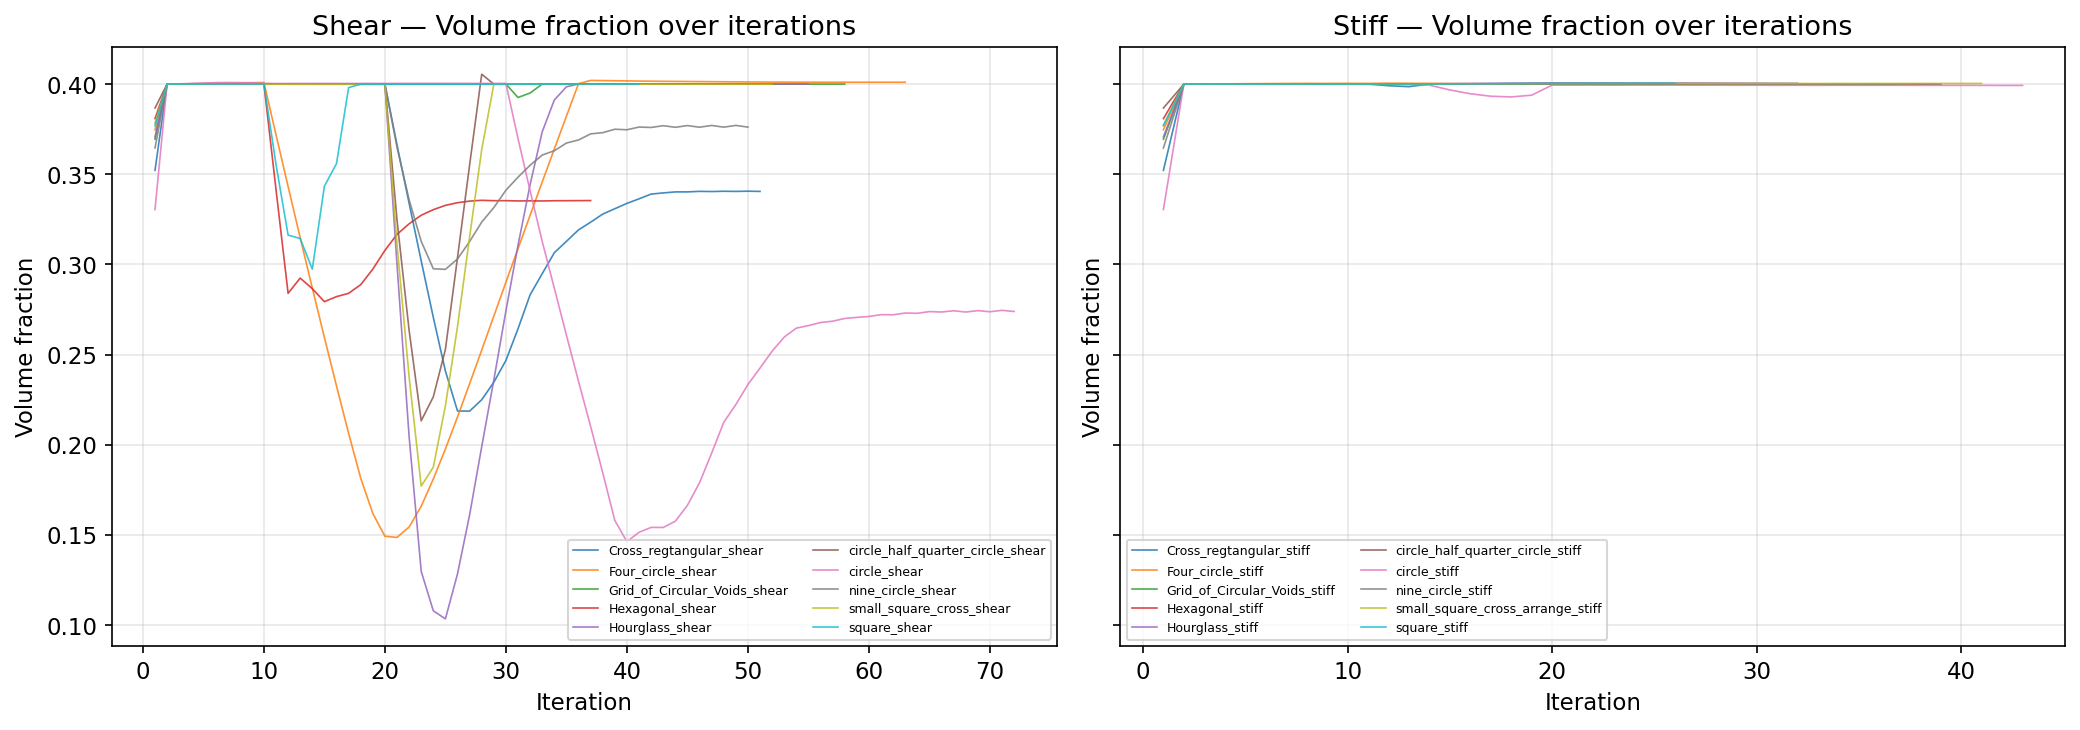

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = df[df['condition'] == cond]
    for seed, grp in sub.groupby('seed'):
        grp = grp.sort_values('iterations')
        ax.plot(grp['iterations'], grp['volume_fractions'],
                label=seed, linewidth=0.8, alpha=0.85)
    ax.set_title(f'{label} — Volume fraction over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Volume fraction')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'convergence_volume.png')
plt.show()

## 4. So sánh tốc độ hội tụ

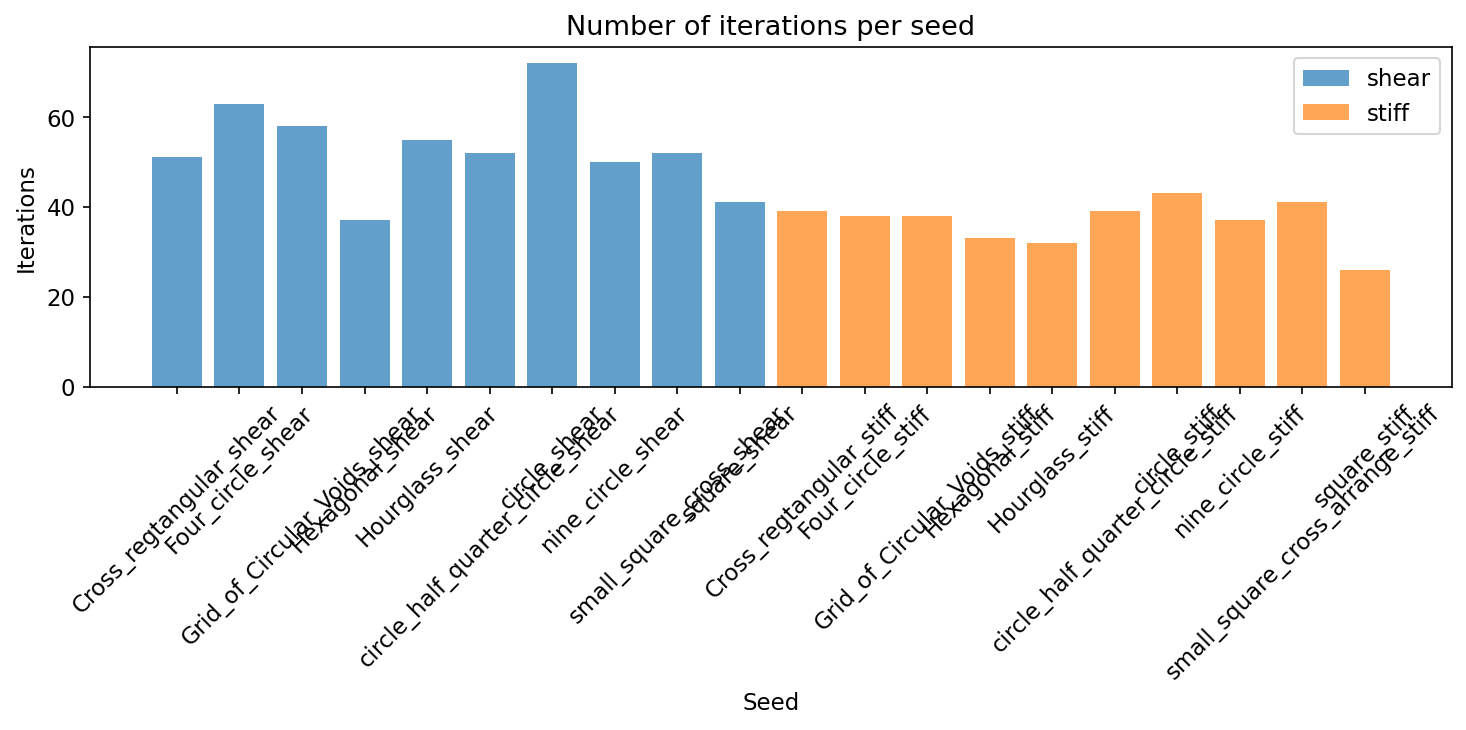

In [17]:
# Số iteration cho mỗi seed
summary = df.groupby(['condition', 'seed'])['iterations'].max().reset_index()
summary.columns = ['condition', 'seed', 'n_iterations']

fig, ax = plt.subplots(figsize=(10, 5))
for cond in ['shear', 'stiff']:
    sub = summary[summary['condition'] == cond]
    ax.bar(sub['seed'], sub['n_iterations'], alpha=0.7, label=cond)
ax.set_title('Number of iterations per seed')
ax.set_xlabel('Seed')
ax.set_ylabel('Iterations')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'convergence_n_iterations.png')
plt.show()

## 5. Final ν₁₂ value per seed

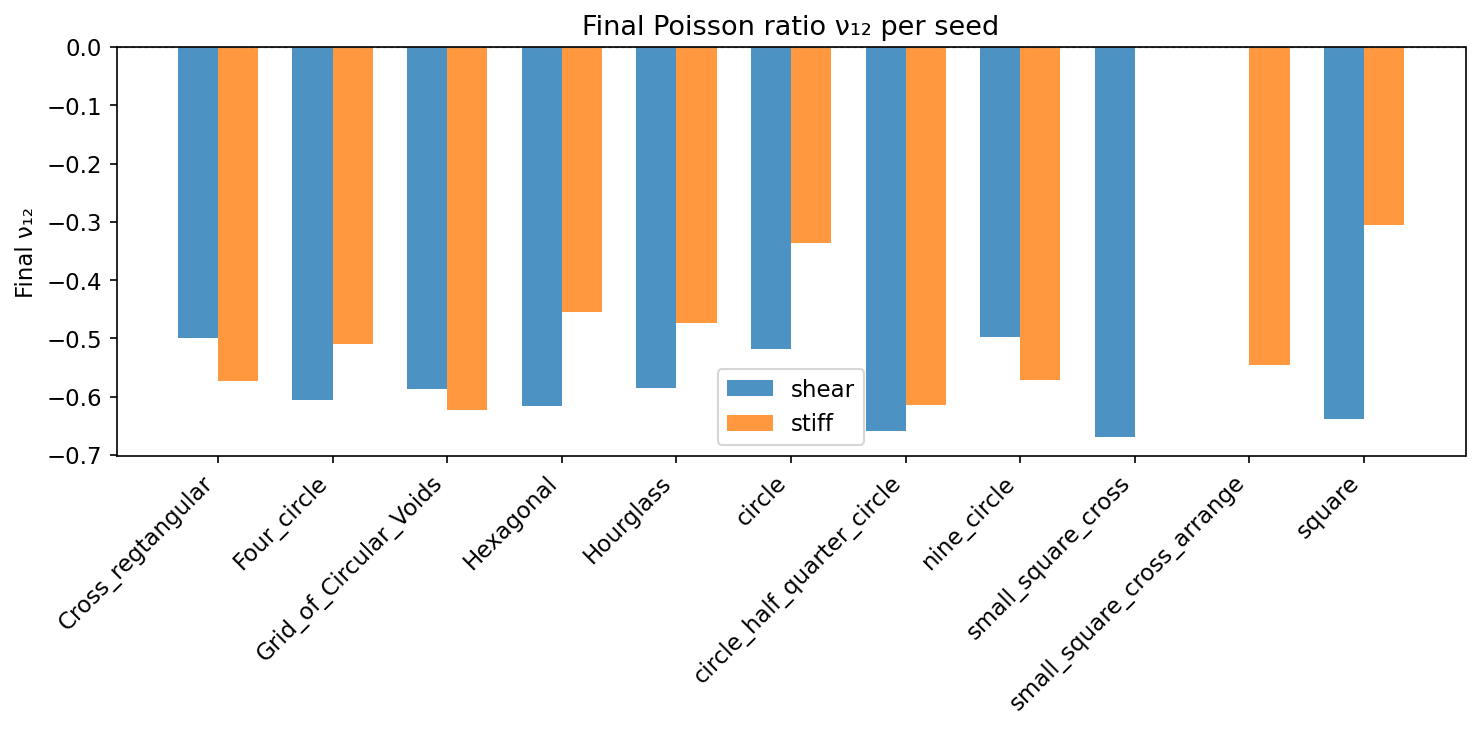

In [18]:
# Lấy giá trị cuối cùng của mỗi seed
final = df.loc[df.groupby(['condition', 'seed'])['iterations'].idxmax()]
# Tạo base_seed bằng cách loại bỏ hậu tố _shear / _stiff
final['base_seed'] = final['seed'].str.replace('_shear$|_stiff$', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))
base_seeds = sorted(final['base_seed'].unique())
x = np.arange(len(base_seeds))
width = 0.35

for i, cond in enumerate(['shear', 'stiff']):
    sub = final[final['condition'] == cond].sort_values('seed')
    # Align to base seeds so missing shapes get 0
    sub_map = sub.set_index('base_seed')['poisson_ratios_v12']
    values = sub_map.reindex(base_seeds).fillna(0)
    ax.bar(x + i*width, values, width, label=cond, alpha=0.8)

ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.6)
ax.set_xticks(x + width/2)
ax.set_xticklabels(base_seeds, rotation=45, ha='right')
ax.set_ylabel('Final ν₁₂')
ax.set_title('Final Poisson ratio ν₁₂ per seed')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'convergence_final_v12.png')
plt.show()

## 6. ν₁₂ evolution — Facet grid per seed

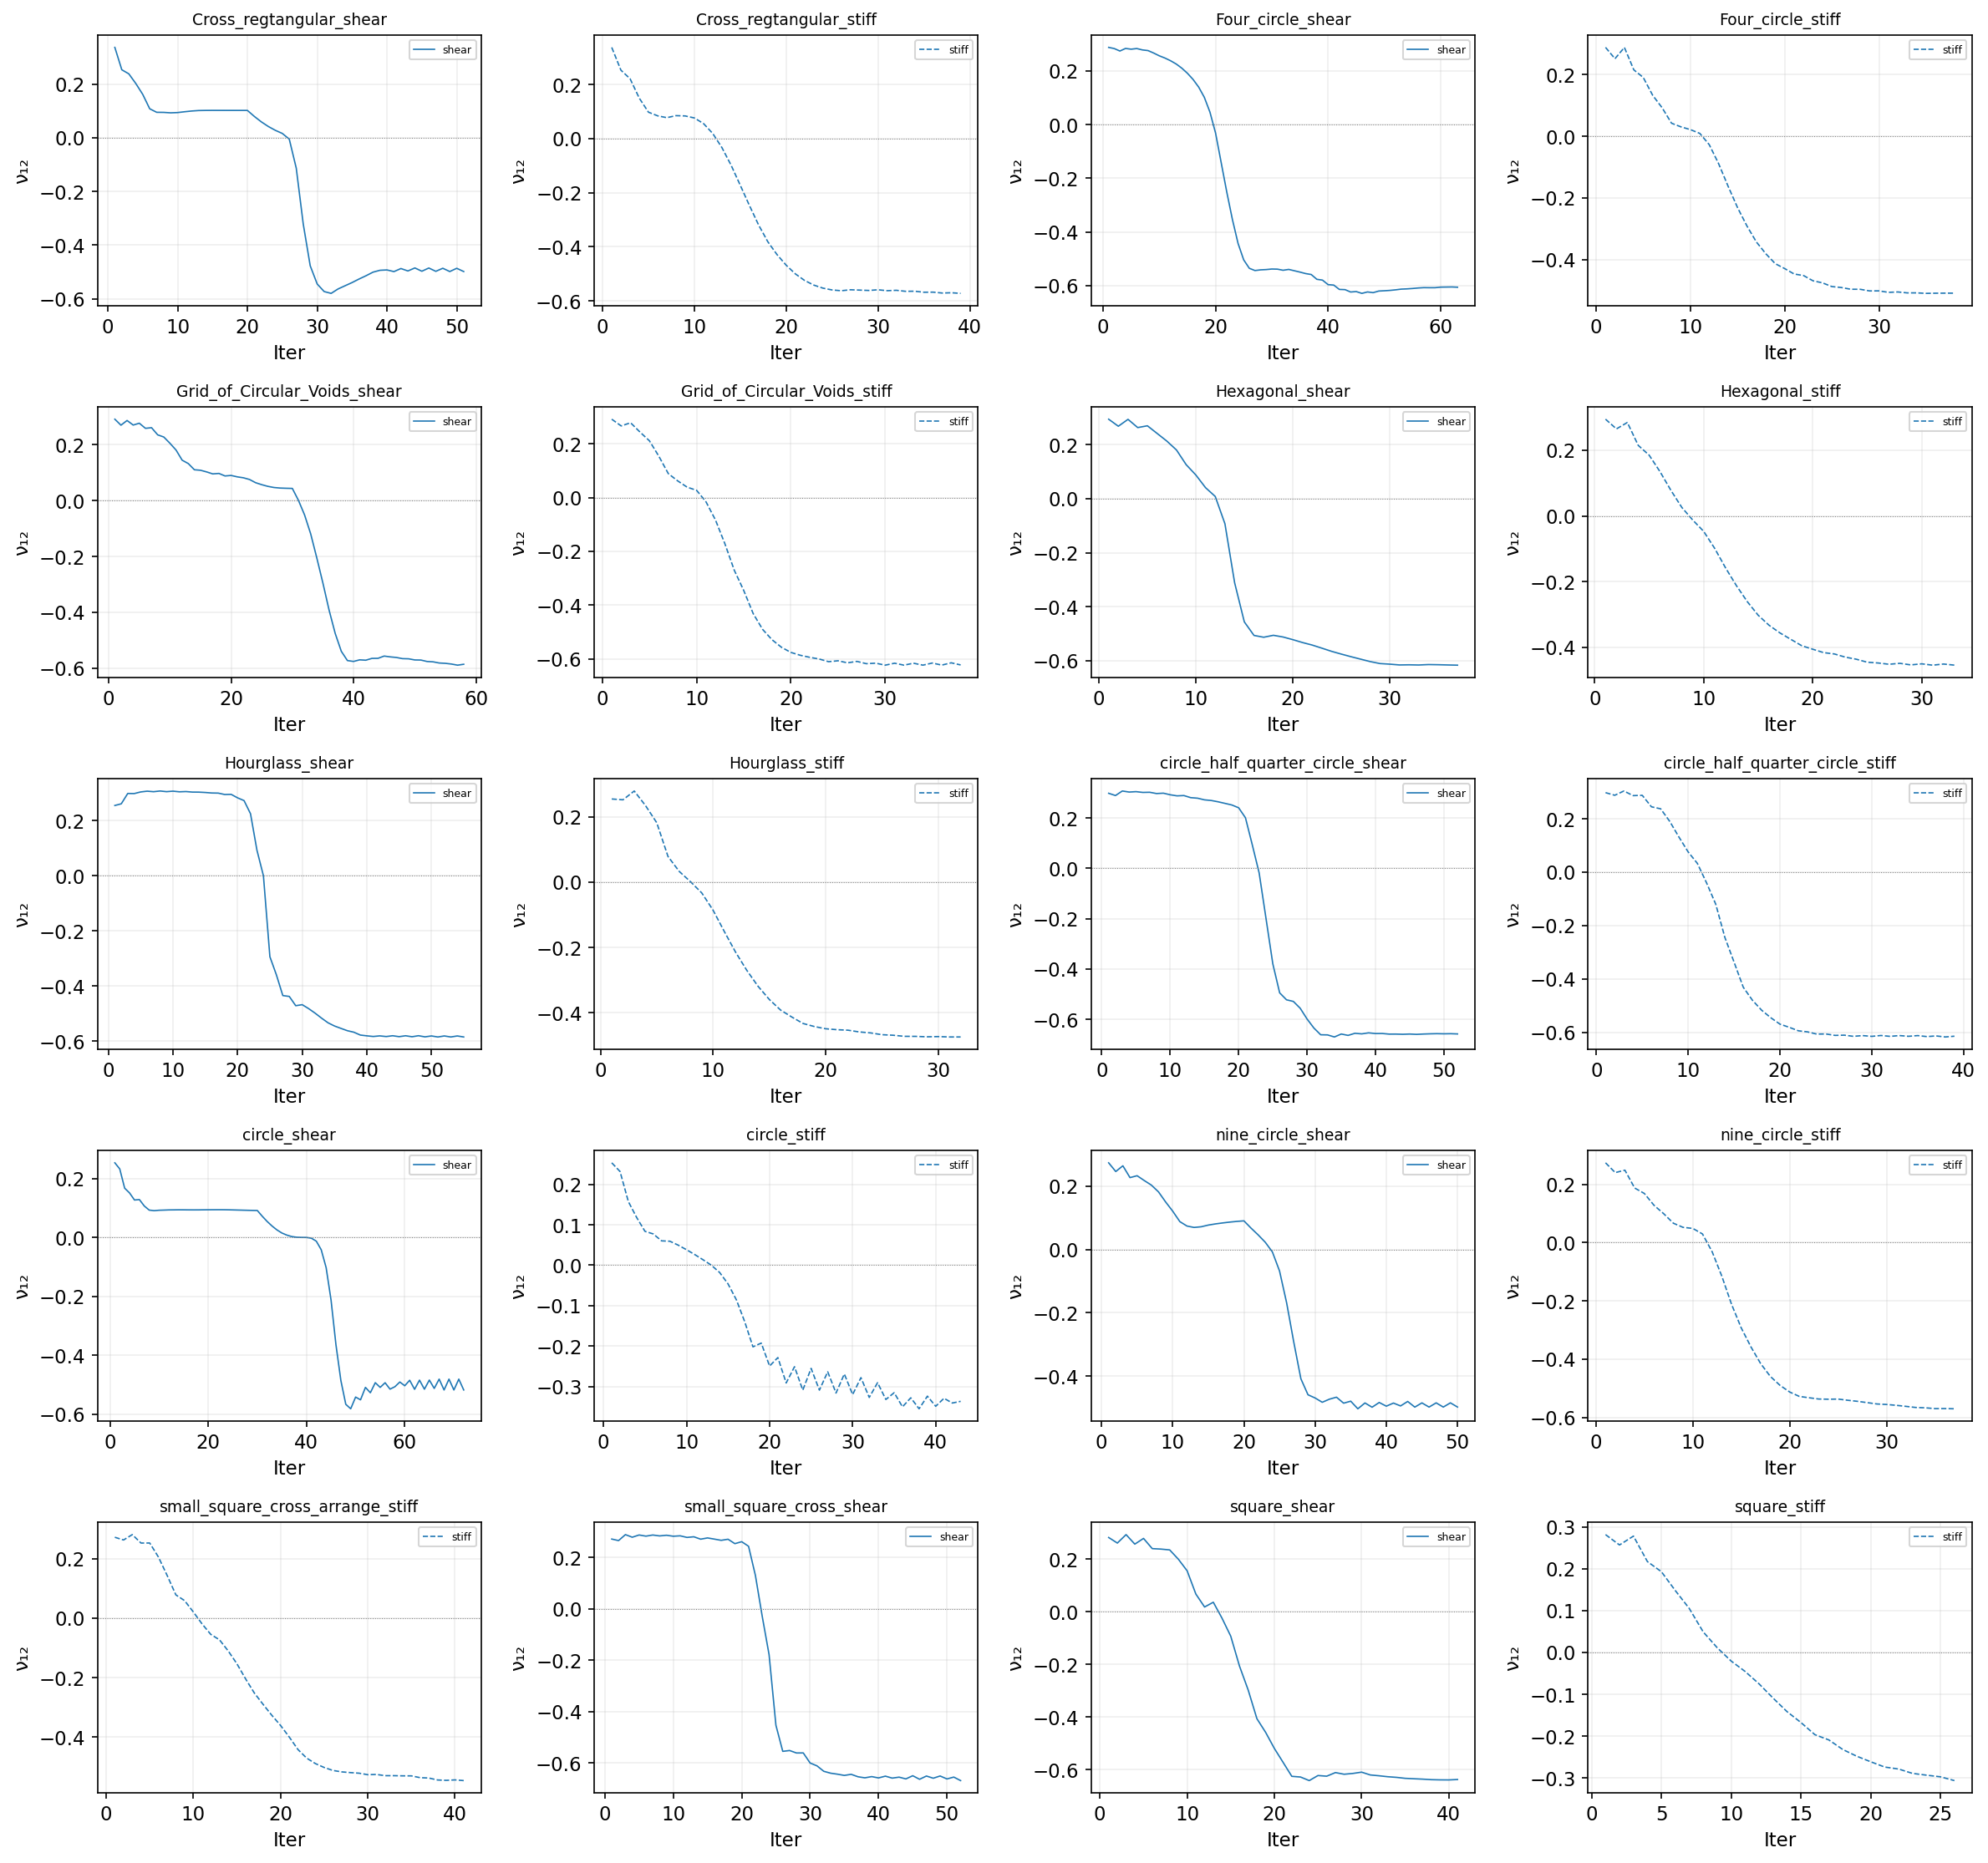

Done — all convergence figures saved to ../outputs/figures


In [19]:
seeds = sorted(df['seed'].unique())
n_seeds = len(seeds)
n_cols = 4
n_rows = int(np.ceil(n_seeds / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, seed in enumerate(seeds):
    ax = axes[i]
    sub = df[df['seed'] == seed].sort_values('iterations')
    for cond, style in [('shear', '-'), ('stiff', '--')]:
        s = sub[sub['condition'] == cond]
        if len(s) > 0:
            ax.plot(s['iterations'], s['poisson_ratios_v12'],
                    style, label=cond, linewidth=0.8)
    ax.axhline(y=0, color='grey', linestyle=':', linewidth=0.5)
    ax.set_title(seed, fontsize=9)
    ax.set_xlabel('Iter')
    ax.set_ylabel('ν₁₂')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'convergence_facet_v12.png')
plt.show()
print('Done — all convergence figures saved to', OUTPUT_DIR)